**Table of contents**<a id='toc0_'></a>    
- [Increasing abundance of short OFF periods in 4 fluorophore systems at 3 nm](#toc1_)    
  - [Data generation](#toc1_1_)    
  - [Data processing and visualization](#toc1_2_)    
    - [Read the data](#toc1_2_1_)    
      - [1x](#toc1_2_1_1_)    
      - [10 x](#toc1_2_1_2_)    
      - [100 x](#toc1_2_1_3_)    
  - [Post-processing](#toc1_3_)    
      - [1 x](#toc1_3_1_1_)    
      - [10 x](#toc1_3_1_2_)    
      - [100 x](#toc1_3_1_3_)    
  - [Figure](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Increasing abundance of short OFF periods in 4 fluorophore systems at 3 nm](#toc0_)

In [ ]:
import logging

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

logging.getLogger("fluopy").setLevel(logging.CRITICAL)  # Only show critical errors
logging.getLogger("fluopy.simulation").setLevel(logging.CRITICAL)


%load_ext autoreload
%autoreload 2

saving_at = r"D:\python_output\Chapter_I\1_13_multi_f_et_adjustments\short_off_periods"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Data generation](#toc0_)

In [3]:
def wrapped(factor, seed, only_transition_set):
    rng = np.random.default_rng(seed)
    fluorophores = fl.construct_fluorophores(
        name="cy5_dna", distance=3, count=4, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = fluorophore_system.load_transitions(
        bleaching=True,
        energy_transfer=True,
        **rt.PARAMS_DSTORM,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    current_rate_pet_tr = transition_set.transition_df.xs(14, level=1)["rate"].iloc[0]
    transition_set = transition_set.adjust_rates({14: current_rate_pet_tr * factor})

    transition_set.finalize()
    if only_transition_set:
        return transition_set

    print(f"Running with factor: {factor}")
    simulation = si.Simulation(transition_set)
    simulation.run(
        size=1e6, end_time=10000, seed=rng, use_memmap=saving_at + rf"\{factor}x"
    )

    shape_state_series = simulation.state_series.shape
    shape_transition_series = simulation.transition_series.shape
    shape_time_series = simulation.time_series.shape
    print(f"state_series shape: {shape_state_series}")
    print(f"transition_series shape: {shape_transition_series}")
    print(f"time_series shape: {shape_time_series}")

In [ ]:
wrapped(1, 42)
# state_series shape: (4, 355567721)
# transition_series shape: (355567720,)
# time_series shape: (355567722,)

In [ ]:
wrapped(10, 42)
# tate_series shape: (4, 423213399)
# transition_series shape: (423213398,)
# time_series shape: (423213400,)

In [ ]:
wrapped(100, 42)
# state_series shape: (4, 506648605)
# transition_series shape: (506648604,)
# time_series shape: (506648606,)

## <a id='toc1_2_'></a>[Data processing and visualization](#toc0_)

### <a id='toc1_2_1_'></a>[Read the data](#toc0_)

#### <a id='toc1_2_1_1_'></a>[1x](#toc0_)

In [4]:
shape_state_series = (4, 355567721)
shape_transition_series = (355567720,)
shape_time_series = (355567722,)
transition_set_1 = wrapped(1, 42, only_transition_set=True)
simulation_1 = si.Simulation(transition_set_1)
simulation_1.state_series = np.memmap(
    saving_at + r"\1x\state_series",
    dtype=np.int8,
    mode="r",
    shape=shape_state_series,
)
simulation_1.transition_series = np.memmap(
    saving_at + r"\1x\transition_series",
    dtype=np.uint32,
    mode="r",
    shape=shape_transition_series,
)
simulation_1.time_series = np.memmap(
    saving_at + r"\1x\time_series",
    dtype=np.float64,
    mode="r",
    shape=shape_time_series,
)

#### <a id='toc1_2_1_2_'></a>[10 x](#toc0_)

In [5]:
shape_state_series = (4, 423213399)
shape_transition_series = (423213398,)
shape_time_series = (423213400,)
transition_set_10 = wrapped(10, 42, only_transition_set=True)
simulation_10 = si.Simulation(transition_set_1)
simulation_10.state_series = np.memmap(
    saving_at + r"\10x\state_series",
    dtype=np.int8,
    mode="r",
    shape=shape_state_series,
)
simulation_10.transition_series = np.memmap(
    saving_at + r"\10x\transition_series",
    dtype=np.uint32,
    mode="r",
    shape=shape_transition_series,
)
simulation_10.time_series = np.memmap(
    saving_at + r"\10x\time_series",
    dtype=np.float64,
    mode="r",
    shape=shape_time_series,
)

#### <a id='toc1_2_1_3_'></a>[100 x](#toc0_)

In [6]:
shape_state_series = (4, 506648605)
shape_transition_series = (506648604,)
shape_time_series = (506648606,)
transition_set_100 = wrapped(100, 42, only_transition_set=True)
simulation_100 = si.Simulation(transition_set_1)
simulation_100.state_series = np.memmap(
    saving_at + r"\100x\state_series",
    dtype=np.int8,
    mode="r",
    shape=shape_state_series,
)
simulation_100.transition_series = np.memmap(
    saving_at + r"\100x\transition_series",
    dtype=np.uint32,
    mode="r",
    shape=shape_transition_series,
)
simulation_100.time_series = np.memmap(
    saving_at + r"\100x\time_series",
    dtype=np.float64,
    mode="r",
    shape=shape_time_series,
)

## <a id='toc1_3_'></a>[Post-processing](#toc0_)

#### <a id='toc1_3_1_1_'></a>[1 x](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
analysis_1 = an.Analysis(simulation_1)

emis_1 = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_1.extract(simulation_1)
rt.emission_post_processing(emis_1, rng)

fcs_1 = fcs_p.FCS(emis_1)
fcs_1.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink_1 = bl.Blinking(emis_1)
copy_on_periods_1 = blink_1.on_periods.copy()

fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 1 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


E:\Vincent\Photoswitching-main\src\fluopy\analysis.py:59: UserWarning: if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0.
  warnings.warn(


#### <a id='toc1_3_1_2_'></a>[10 x](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
analysis_10 = an.Analysis(simulation_10)

emis_10 = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_10.extract(simulation_10)
rt.emission_post_processing(emis_10, rng)

fcs_10 = fcs_p.FCS(emis_10)
fcs_10.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink_10 = bl.Blinking(emis_10)
copy_on_periods_10 = blink_10.on_periods.copy()

fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 1 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


E:\Vincent\Photoswitching-main\src\fluopy\analysis.py:59: UserWarning: if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0.
  warnings.warn(


#### <a id='toc1_3_1_3_'></a>[100 x](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
analysis_100 = an.Analysis(simulation_100)

emis_100 = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_100.extract(simulation_100)
rt.emission_post_processing(emis_100, rng)

fcs_100 = fcs_p.FCS(emis_100)
fcs_100.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink_100 = bl.Blinking(emis_100)
copy_on_periods_100 = blink_100.on_periods.copy()

fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 1 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


E:\Vincent\Photoswitching-main\src\fluopy\analysis.py:59: UserWarning: if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0.
  warnings.warn(


## <a id='toc1_4_'></a>[Figure](#toc0_)

C:\Users\fkt17ba\AppData\Local\Temp\ipykernel_27780\3896902009.py:278: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\fkt17ba\AppData\Local\Temp\ipykernel_27780\3896902009.py:279: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
E:\Vincent\uv_envs\phd_main\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
E:\Vincent\uv_envs\phd_main\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


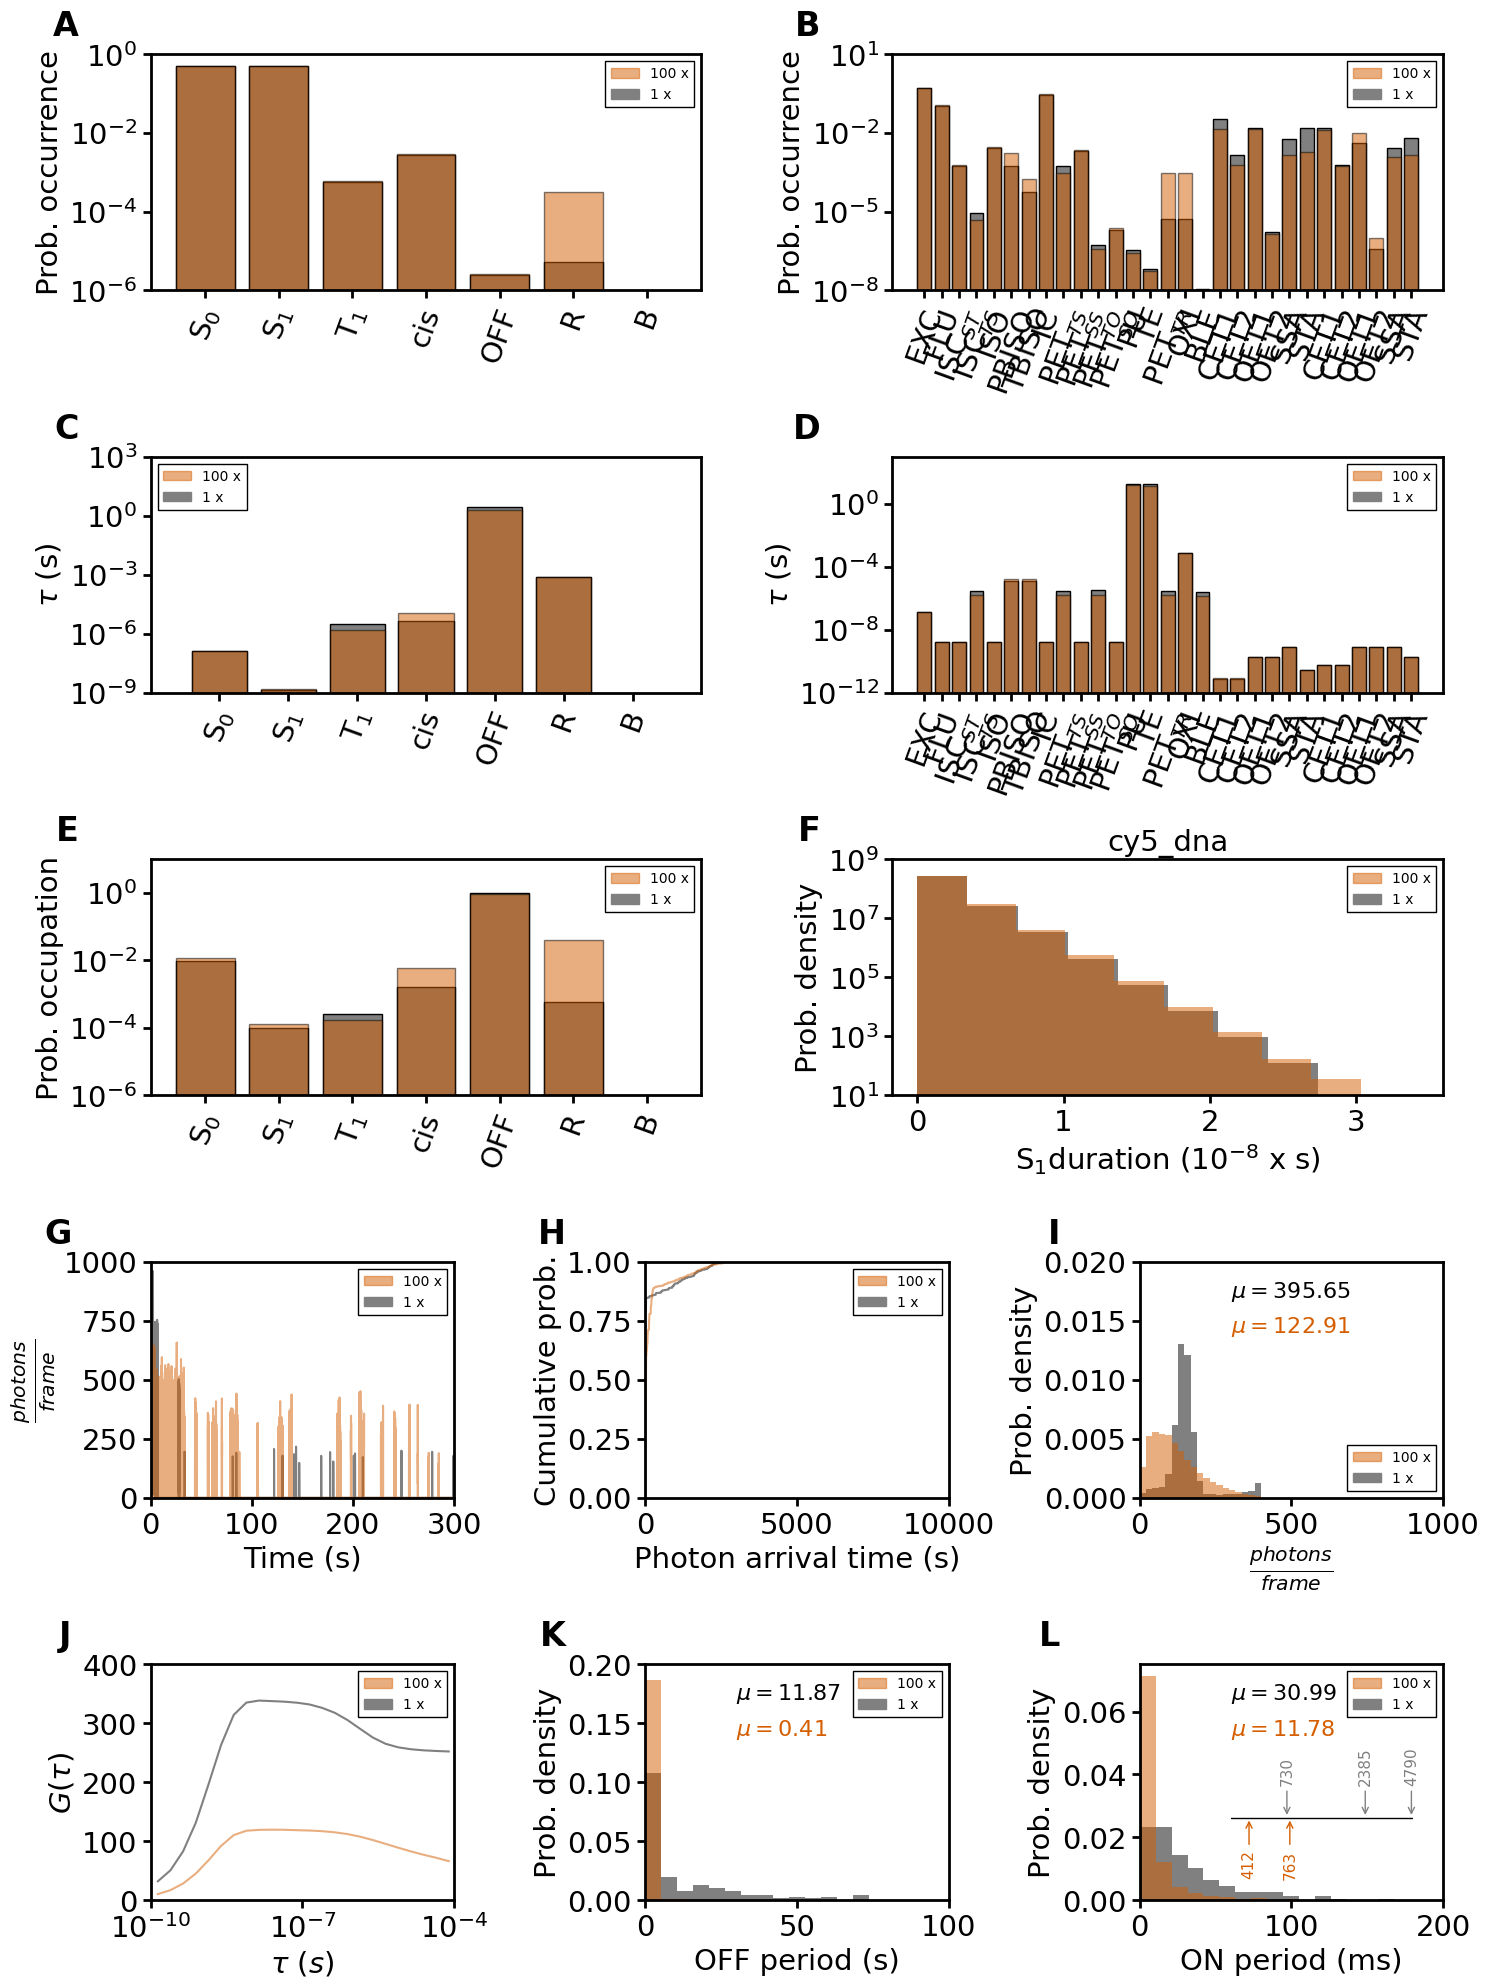

In [ ]:
red = "#D55E00"


def draw_legend(ax):
    ax.legend(
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=10,
        handles=[
            mpl.patches.Patch(color=red, label="100 x", alpha=0.5),
            mpl.patches.Patch(color="grey", label="1 x"),
        ],
    )


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
ax = fig.add_subplot(gs[0, 0:3])
analysis_1.plot_frequency_states(axes=ax, color="grey")
analysis_100.plot_frequency_states(
    ylim=[1e-6, 1e0],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[0, 3:])
analysis_1.plot_frequency_transitions(
    axes=ax,
    color="grey",
)
analysis_100.plot_frequency_transitions(
    ylim=[1e-8, 1e1],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[1, 0:3])
analysis_1.plot_mean_lifetimes(
    axes=ax,
    color="grey",
)
analysis_100.plot_mean_lifetimes(
    ylim=[1e-9, 1e3],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[1, 3:])
analysis_1.plot_mean_transition_times(
    axes=ax,
    color="grey",
)
analysis_100.plot_mean_transition_times(
    ylim=[1e-12, 1e3],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[2, 0:3])
analysis_1.plot_state_occupations(
    axes=ax,
    color="grey",
)
analysis_100.plot_state_occupations(
    ylim=[1e-6, 1e1],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[2, 3:])
analysis_1.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    color="grey",
)
analysis_100.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    color=red,
    alpha=0.5,
    title=None,
    ylim=[1e1, 1e9],
    tick_style_x="sci",
)
draw_legend(ax)

ax = fig.add_subplot(gs[3, 0:2])
emis_1.plot_time_series(
    axes=ax,
    color="grey",
    xlim=[0, 300],
    ylim=[0, 1000],
)
emis_100.plot_time_series(axes=ax, color=red, alpha=0.5)
draw_legend(ax)
ax = fig.add_subplot(gs[3, 2:4])
emis_1.plot_cumulative_events(axes=ax, color="grey", xlim=[0, 10000])
emis_100.plot_cumulative_events(
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[3, 4:])
bins = np.linspace(0, 400, 20)
emis_1.plot_histogram(
    axes=ax,
    color="grey",
    ylim=[0, 0.02],
    xlim=[0, 1000],
    bins=bins,
    display_mean=True,
)
emis_100.plot_histogram(
    axes=ax,
    color=red,
    bins=bins,
    alpha=0.5,
    display_mean=False,
)
ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {122.91}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)

ax = fig.add_subplot(gs[4, 0:2])
fcs_1.plot(
    axes=ax,
    unit="s",
    color="grey",
    title=None,
)
fcs_100.plot(
    axes=ax,
    unit="s",
    color=red,
    title=None,
    xlim=[1e-10, 1e-4],
    ylim=[0, 400],
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[4, 2:4])
bins = np.linspace(0, 100, 20)
blink_1.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    ylim=[0, 0.2],
    xlim=[0, 100],
    color="grey",
    bins=bins,
    display_mean=True,
)
blink_100.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    ylim=[0, 0.2],
    xlim=[0, 100],
    color=red,
    alpha=0.5,
    bins=bins,
    display_mean=False,
)
ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {0.41}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)
ax = fig.add_subplot(gs[4, 4:])
bins = np.linspace(0, 200, 20)
blink_1.on_periods = blink_1.on_periods[blink_1.on_periods < 400]
blink_1.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    ylim=[0, 0.075],
    xlim=[0, 200],
    color="grey",
    bins=bins,
    display_mean=True,
)

inset = ax.inset_axes(
    [0.3, 0.1, 0.6, 0.5],
)
inset.axhline(0, color="black", lw=1)
outliers_1 = copy_on_periods_1[copy_on_periods_1 > 400]
outliers_100 = copy_on_periods_100[copy_on_periods_100 > 400]
outliers_all = np.concatenate([outliers_1, outliers_100])
inset.plot(outliers_1, np.zeros_like(outliers_1), marker="", linestyle="")
inset.set_xlim([min(outliers_all) - 100, max(outliers_all) + 100])
inset.set_xscale("log")
inset.axis("off")
for outlier in outliers_1:
    inset.annotate(
        f"{outlier}",
        xy=(outlier, 0),
        xytext=(outlier, 0.03),
        textcoords="data",
        ha="center",
        va="bottom",
        arrowprops=dict(arrowstyle="->", color="grey"),
        fontsize=11,
        color="grey",
        rotation=90,
    )

blink_100.on_periods = blink_100.on_periods[blink_100.on_periods < 400]
blink_100.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    ylim=[0, 0.075],
    xlim=[0, 200],
    color=red,
    alpha=0.5,
    bins=bins,
    display_mean=False,
)
inset.plot(outliers_100, np.zeros_like(outliers_100), marker="", linestyle="")
for outlier in outliers_100:
    inset.annotate(
        f"{outlier}",
        xy=(outlier, 0),
        xytext=(outlier, -0.03),
        textcoords="data",
        ha="center",
        va="top",
        arrowprops=dict(arrowstyle="->", color=red),
        fontsize=11,
        color=red,
        rotation=90,
    )

ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {11.78}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)
axes = fig.get_axes()
for i, (axis, letter) in enumerate(
    zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"])
):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
fig.savefig(
    saving_at + r"\short_off_periods.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=300,
)